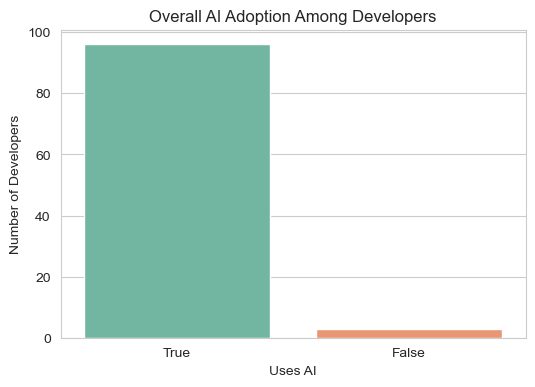

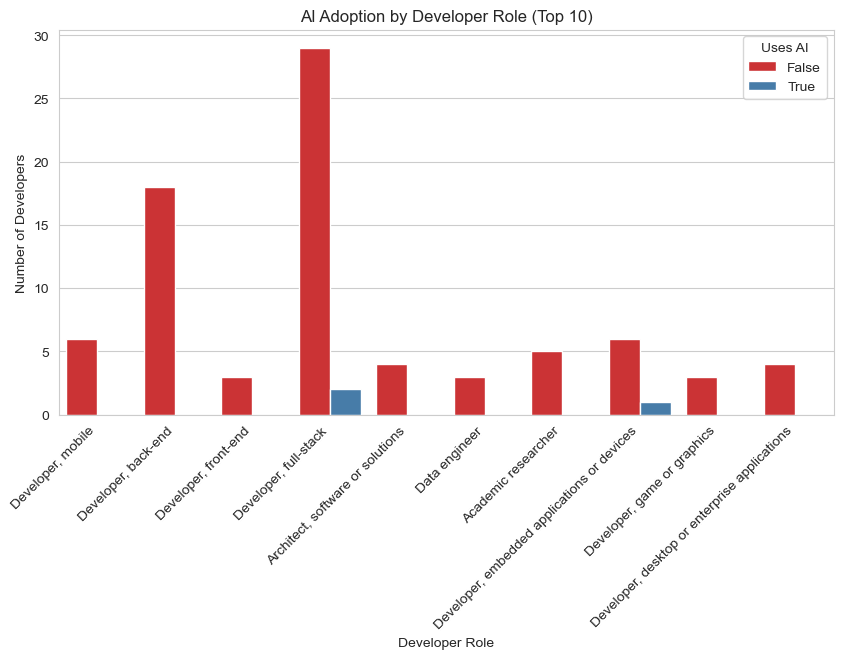

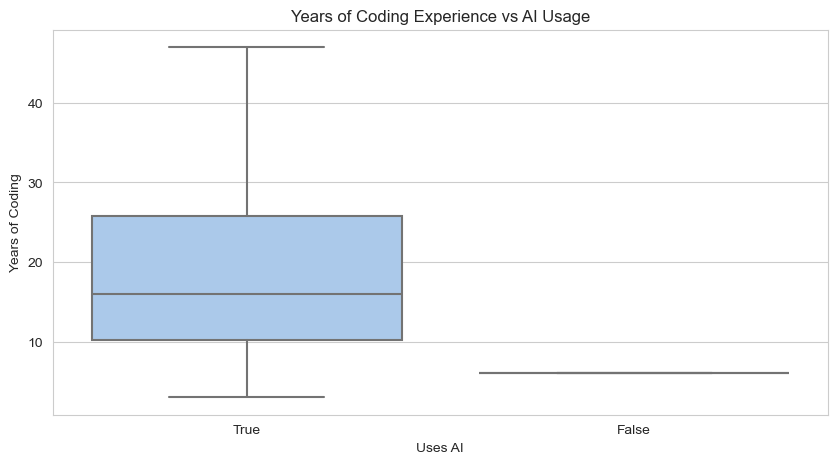

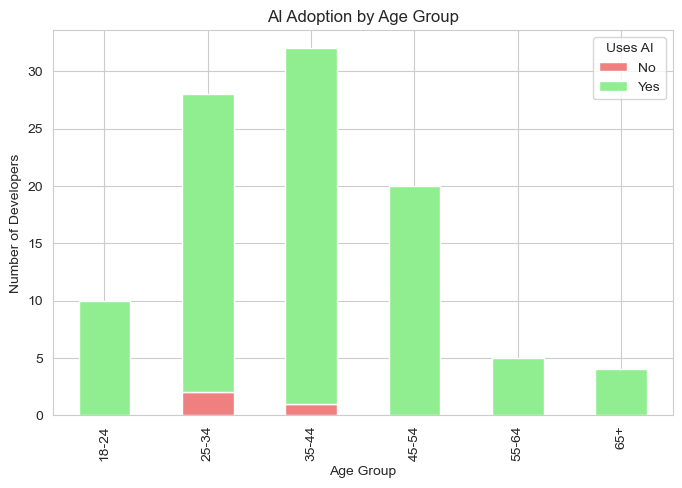

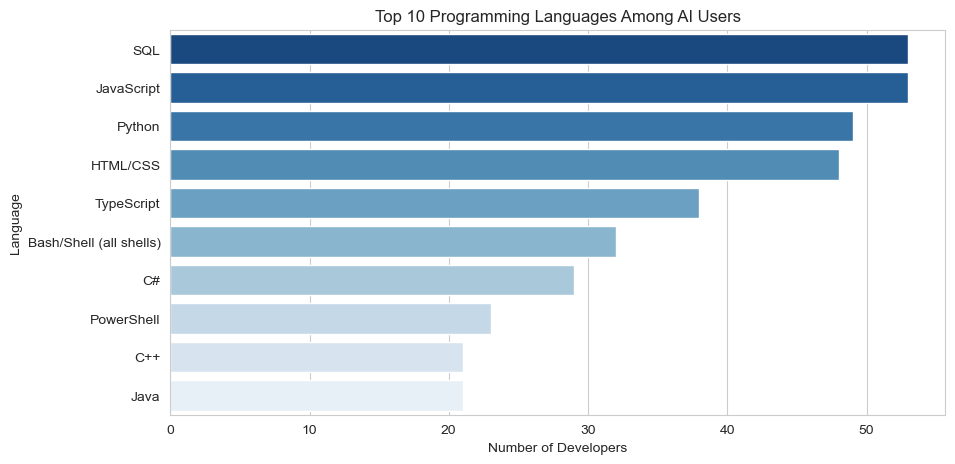

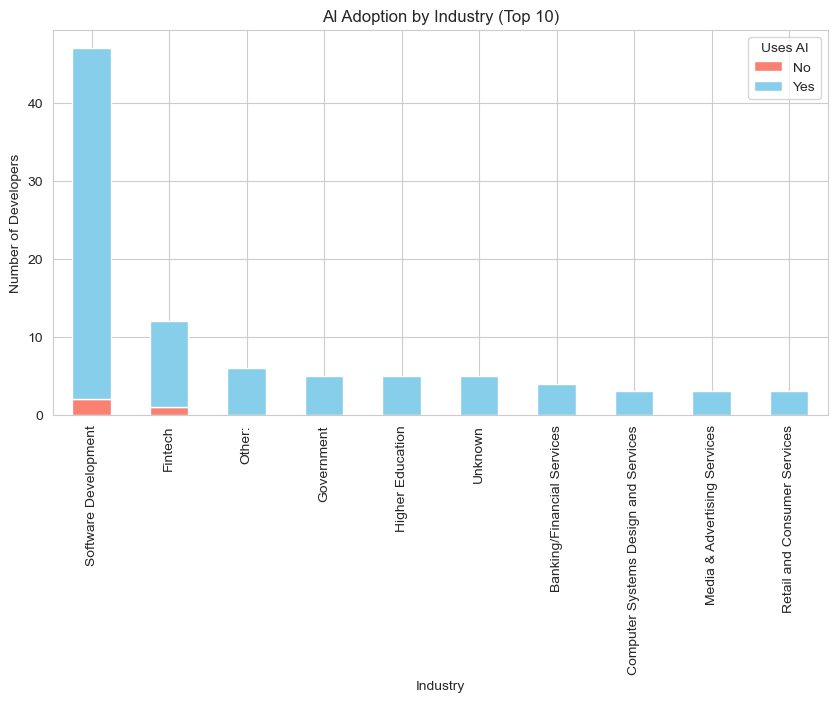

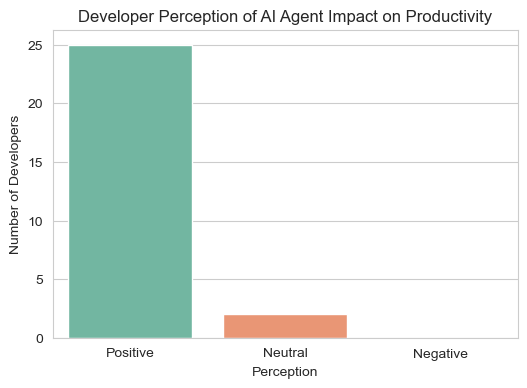

All visualizations displayed and saved in ./Figures/
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00        19

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Classification report saved in ./Figures/classification_report.txt


In [3]:
"""
======================================================================
Artificial Intelligence and the Changing IT Workforce
Arulsree Mozhi Thangaraj Santhakumar

Dataset:
Stack Overflow Developer Survey 2023 dataset containing global developer responses,
including demographic information, professional roles, programming experience,
industry affiliation, and artificial intelligence usage indicators.

Model Implemented:
Random Forest Classification model used to predict AI adoption among developers
based on role, coding experience, age group, and industry.

Outputs:
- Model evaluation metrics including Accuracy, Precision, Recall, and F1-score
- Classification report summarizing predictive performance
- Seven exploratory visualizations illustrating AI adoption trends
- Saved figures and classification report in the project output folder
======================================================================
"""

# ==============================
# Artificial Intelligence and the Changing IT Workforce
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------
# Step 0: Create folder for visuals
# ---------------------------
output_folder = "../Figures"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# ---------------------------
# Step 1: Load dataset
# ---------------------------
df = pd.read_csv("../Data/dataset_sample.csv", low_memory=False)

# ---------------------------
# Step 2: Preprocess key columns
# ---------------------------
df['DevType'] = df['DevType'].fillna("Unknown")
df['PrimaryDevType'] = df['DevType'].apply(lambda x: x.split(';')[0].strip())
df['UsesAI'] = df['AISelect'].notna() | df['AIToolCurrently mostly AI'].notna()
df['UsesAI_str'] = df['UsesAI'].astype(str)  # For plotting
df['YearsCode'] = pd.to_numeric(df['YearsCode'], errors='coerce')

age_map = {
    'Under 18 years old':'<18',
    '18-24 years old':'18-24',
    '25-34 years old':'25-34',
    '35-44 years old':'35-44',
    '45-54 years old':'45-54',
    '55-64 years old':'55-64',
    '65 years or older':'65+'
}
df['AgeGroup'] = df['Age'].map(age_map)
df['Industry'] = df['Industry'].fillna("Unknown")

sns.set_style("whitegrid")

# ---------------------------
# Step 3: Visualizations
# ---------------------------
def save_and_show(fig, filename):
    fig.savefig(f"{output_folder}/{filename}", bbox_inches='tight')
    plt.show()  # display the figure

# 1. Overall AI Adoption
plt.figure(figsize=(6,4))
sns.countplot(x='UsesAI_str', data=df, palette='Set2')
plt.title("Overall AI Adoption Among Developers")
plt.xlabel("Uses AI")
plt.ylabel("Number of Developers")
save_and_show(plt.gcf(), "ai_adoption_overall.png")

# 2. AI Adoption by DevType (Top 10)
top_roles = df['PrimaryDevType'].value_counts().nlargest(10).index
plt.figure(figsize=(10,5))
sns.countplot(x='PrimaryDevType', hue='UsesAI_str', 
              data=df[df['PrimaryDevType'].isin(top_roles)], palette='Set1')
plt.title("AI Adoption by Developer Role (Top 10)")
plt.xlabel("Developer Role")
plt.ylabel("Number of Developers")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Uses AI', labels=['False','True'])
save_and_show(plt.gcf(), "ai_by_role.png")

# 3. Years of Coding vs AI Usage
plt.figure(figsize=(10,5))
sns.boxplot(x='UsesAI_str', y='YearsCode', data=df, palette='pastel')
plt.title("Years of Coding Experience vs AI Usage")
plt.xlabel("Uses AI")
plt.ylabel("Years of Coding")
save_and_show(plt.gcf(), "ai_by_experience.png")

# 4. AI Adoption by Age Group
age_counts = df.groupby(['AgeGroup','UsesAI_str']).size().reset_index(name='count')
age_pivot = age_counts.pivot(index='AgeGroup', columns='UsesAI_str', values='count').fillna(0)
age_pivot = age_pivot[['False','True']]
age_pivot.plot(kind='bar', stacked=True, figsize=(8,5), color=['lightcoral','lightgreen'])
plt.title("AI Adoption by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Developers")
plt.legend(title='Uses AI', labels=['No','Yes'])
save_and_show(plt.gcf(), "ai_by_age.png")

# 5. Top Languages Among AI Users
df_ai = df[df['UsesAI']]
langs_series = df_ai['LanguageHaveWorkedWith'].dropna().str.split(';').explode().str.strip()
top_langs = langs_series.value_counts().nlargest(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_langs.values, y=top_langs.index, palette='Blues_r')
plt.title("Top 10 Programming Languages Among AI Users")
plt.xlabel("Number of Developers")
plt.ylabel("Language")
save_and_show(plt.gcf(), "top_languages_ai.png")

# 6. AI Adoption by Industry (Top 10)
industry_counts = df.groupby(['Industry','UsesAI_str']).size().reset_index(name='count')
industry_pivot = industry_counts.pivot(index='Industry', columns='UsesAI_str', values='count').fillna(0)
industry_pivot['Total'] = industry_pivot.sum(axis=1)
industry_pivot = industry_pivot.sort_values(by='Total', ascending=False).head(10)
industry_pivot[['False','True']].plot(kind='bar', stacked=True, figsize=(10,5), color=['salmon','skyblue'])
plt.title("AI Adoption by Industry (Top 10)")
plt.xlabel("Industry")
plt.ylabel("Number of Developers")
plt.legend(title='Uses AI', labels=['No','Yes'])
save_and_show(plt.gcf(), "ai_by_industry.png")

# 7. Developer Perception of AI Agent Impact
def impact_category(row):
    if pd.notna(row['AIAgentImpactStrongly agree']) or pd.notna(row['AIAgentImpactSomewhat agree']):
        return "Positive"
    elif pd.notna(row['AIAgentImpactNeutral']):
        return "Neutral"
    elif pd.notna(row['AIAgentImpactSomewhat disagree']) or pd.notna(row['AIAgentImpactStrongly disagree']):
        return "Negative"
    else:
        return "Unknown"
df['AIImpactPerception'] = df.apply(impact_category, axis=1)
plt.figure(figsize=(6,4))
sns.countplot(x='AIImpactPerception', data=df, order=['Positive','Neutral','Negative'], palette='Set2')
plt.title("Developer Perception of AI Agent Impact on Productivity")
plt.xlabel("Perception")
plt.ylabel("Number of Developers")
save_and_show(plt.gcf(), "ai_agent_perception.png")

print("All visualizations displayed and saved in ./Figures/")

# ---------------------------
# Step 4: Classification Report
# ---------------------------
features = ['PrimaryDevType', 'YearsCode', 'AgeGroup', 'Industry']
df_model = df[features + ['UsesAI']].dropna()

# Encode categorical features
for col in ['PrimaryDevType', 'AgeGroup', 'Industry']:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

X = df_model[features]
y = df_model['UsesAI'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

with open(f"{output_folder}/classification_report.txt", 'w') as f:
    f.write(report)

print("Classification report saved in ./Figures/classification_report.txt")